In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("deepcontractor/200k-short-texts-for-humor-detection")

print("Path to dataset files:", path)

100%|██████████| 6.00M/6.00M [00:01<00:00, 4.61MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/deepcontractor/200k-short-texts-for-humor-detection/versions/1


In [2]:
import shutil

shutil.copytree(path, "/content/humor_dataset")

'/content/humor_dataset'

In [3]:
import pandas as pd
df = pd.read_csv("/content/humor_dataset/dataset.csv")
df.head()

,text,humor
0,"Joe biden rules out 2020 bid: 'guys, i'm not r...",False
1,Watch: darvish gave hitter whiplash with slow ...,False
2,What do you call a turtle without its shell? d...,True
3,5 reasons the 2016 election feels so personal,False
4,"Pasco police shot mexican migrant from behind,...",False


In [4]:
print(df['humor'].dtype)

bool


Cleaning the dataset required some special decisions. Since this is a humorous text dataset, we can't really remove punctuation (!, ??, ...) as this is improtant to retain the humor within the text. I also decided not to make the text lowercase as that also plays a factor in humor (SURE BUDDY is different than sure buddy).


In [5]:
df['text'] = df['text'].str.strip()
df['humor'] = df['humor'].astype(int)
df.head()


,text,humor
0,"Joe biden rules out 2020 bid: 'guys, i'm not r...",0
1,Watch: darvish gave hitter whiplash with slow ...,0
2,What do you call a turtle without its shell? d...,1
3,5 reasons the 2016 election feels so personal,0
4,"Pasco police shot mexican migrant from behind,...",0


Now that the text is clean and ready to move on, I do some EDA to discover class balance, length of each joke, etc

In [6]:
df['humor'].value_counts()

,count
humor,
0,100000
1,100000


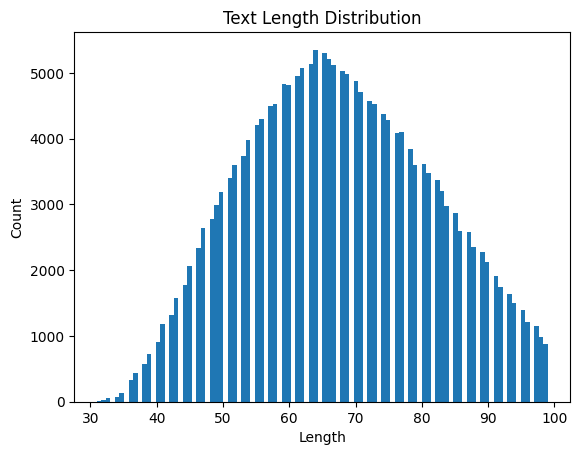

In [7]:
import matplotlib.pyplot as plt
#plot the text length counts
df['length'] = df['text'].apply(len)
plt.hist(df['length'], bins=100)
plt.title("Text Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()


The text length(characters) follows a normal distribution. We also have no class imbalance as there is a 1:1 ratio of humourous text to non-humourous text.

In [8]:
df.groupby('humor')['length'].mean()


,length
humor,
0,64.94949
1,69.99166


In [9]:
from scipy.stats import ttest_ind

group0 = df[df['humor'] == 0]['length']
group1 = df[df['humor'] == 1]['length']

t_stat, p_value = ttest_ind(group0, group1, equal_var=False)

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: -80.90396877066003
p-value: 0.0


This p-value is statistially significant. Meaning that the length of the text of humourous text is statistically different from the length of non-humourous text. However, this alone does not predict humor.

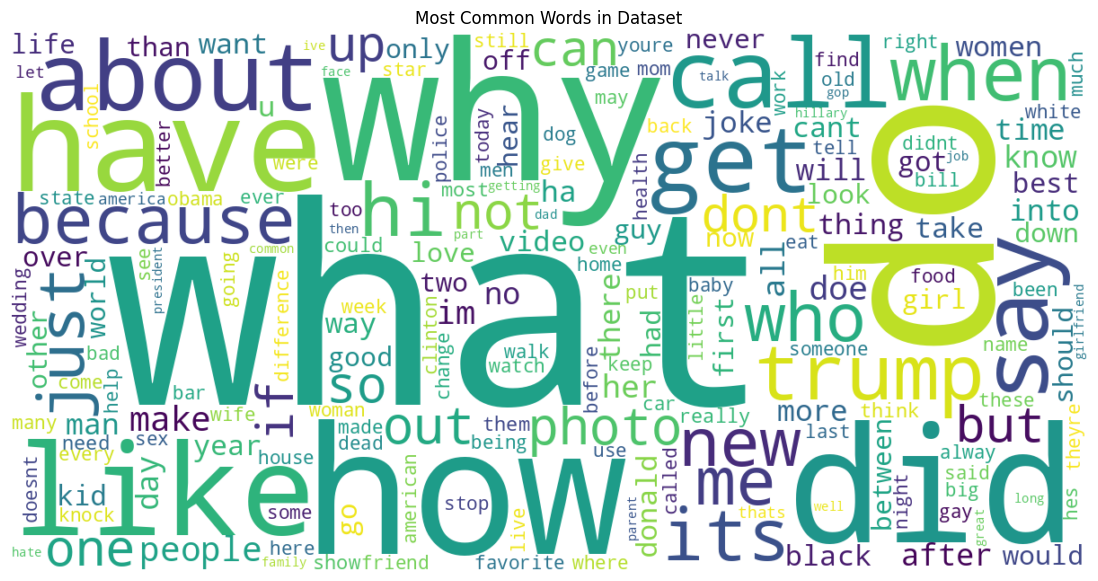

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

# Combine all text
all_text = " ".join(df["text"].astype(str))

# Lowercase
all_text = all_text.lower()

# Remove punctuation/numbers
all_text = re.sub(r"[^a-zA-Z\s]", "", all_text)

# Optional stopwords
stopwords = {
    "the", "a", "an", "and", "or", "is", "it", "to", "of",
    "in", "that", "this", "for", "on", "with", "as", "was",
    "are", "be", "at", "by", "from", "i", "you", "he", "she",
    "they", "we", "my", "your", "our", "their"
}

# Create word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=stopwords,
    collocations=False
).generate(all_text)

# Plot
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Dataset")
plt.show()

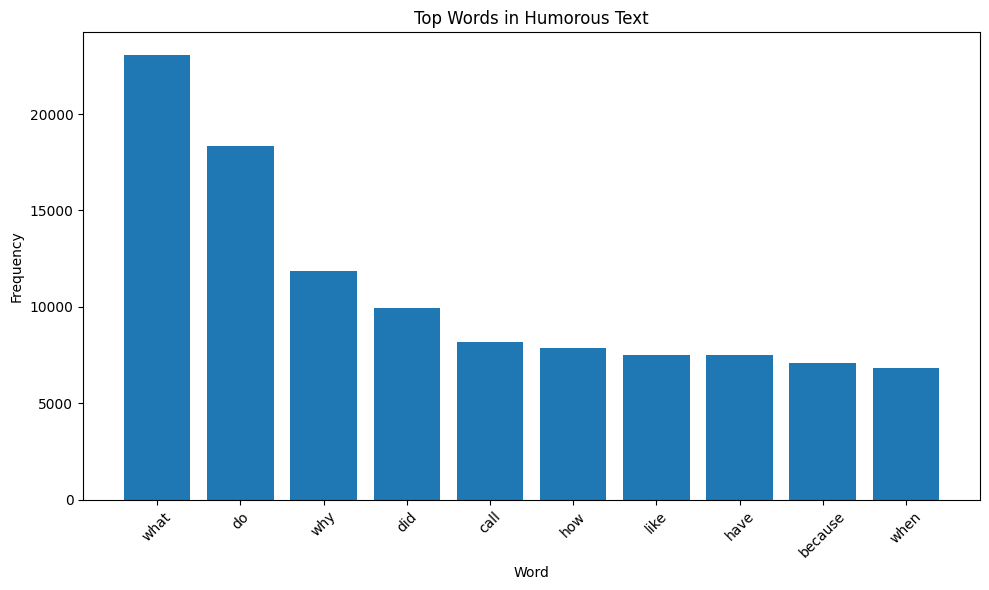

In [11]:
from collections import Counter

# Function to get top words
def get_top_words(text_series, top_n=10):
    text = " ".join(text_series.astype(str)).lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = [word.strip() for word in text.split()]
    words = [word for word in words if word not in stopwords]

    counter = Counter(words)

    return pd.DataFrame(counter.most_common(top_n),
                        columns=["Word", "Count"])

# Split by class
humor_df = df[df["humor"] == 1]
nonhumor_df = df[df["humor"] == 0]

# Get top words
top_humor = get_top_words(humor_df["text"])
top_nonhumor = get_top_words(nonhumor_df["text"])

# Plot humorous words
plt.figure(figsize=(10,6))
plt.bar(top_humor["Word"], top_humor["Count"])
plt.xticks(rotation=45)
plt.title("Top Words in Humorous Text")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


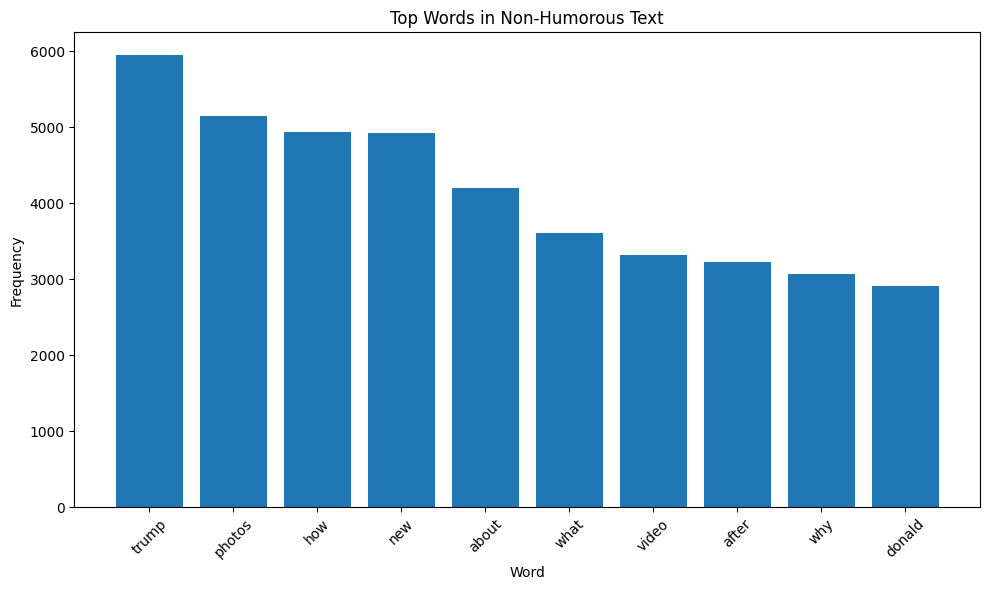

In [12]:
# Plot non-humorous words
plt.figure(figsize=(10,6))
plt.bar(top_nonhumor["Word"], top_nonhumor["Count"])
plt.xticks(rotation=45)
plt.title("Top Words in Non-Humorous Text")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from transformers import RobertaTokenizer

#split 70/30
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["text"].tolist(),
    df["humor"].tolist(),
    test_size=0.3,
    random_state=1,
    stratify=df["humor"]
)
#split 50/50 from the remaining 30
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.50,
    random_state=1,
    stratify=temp_labels
)

#tokenize train, val, train splits
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [14]:
print(df["text"][9])
print(train_encodings["input_ids"][9])
print(train_encodings["attention_mask"][9])

My family tree is a cactus, we're all pricks.
[0, 574, 108, 43434, 2242, 354, 817, 3575, 6198, 19, 33811, 12, 605, 10852, 524, 4242, 449, 4134, 11, 2549, 637, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


Everything looks correct. 0 represents s or the start of the sequence. 19993, 1239, 4374, 23, 637, 3198, 11, 13011, 1594, 43052, 1304 represents the actual tokens. 2 represents the end of the sequence and the 1s represent the padding to size 128. For the attention mask, the 1s represent actual tokens while the 0s represent the padded size to 128.

In [15]:
import torch
from torch.utils.data import Dataset

class HumorDataset(Dataset):

  def __init__(self, encodings, labels):
    self.encodings = encodings
    self.labels = labels

  def __getitem__(self, i):
    #for each key(input_ids, attention_mask) and val(label) we convert them to a tensor
    item = {key: torch.tensor(val[i]) for key, val in self.encodings.items()}
    item["labels"] = torch.tensor(self.labels[i])
    return item

  def __len__(self):
    return len(self.labels)


train_dataset = HumorDataset(train_encodings, train_labels)
val_dataset = HumorDataset(val_encodings, val_labels)
test_dataset = HumorDataset(test_encodings, test_labels)

In [16]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [17]:
from transformers import RobertaForSequenceClassification
from torch.optim import AdamW
import numpy as np

#binary classification
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

#use cuda if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [18]:

def train(model, train_loader, val_loader, optimizer, device, num_epochs, save_path):
  #initialize tracker for minimum validation loss
  valid_loss_min = np.inf
  for epoch in range(num_epochs):
      #initialize variables to monitor training and validation loss
      train_loss = 0.0
      valid_loss = 0.0

      ######################
      # train the model #
      ######################

      #set model to training mode
      model.train()

      for batch_idx, batch in enumerate(train_loader):

          #move every tensor(inputs + labels) in batch to the same device as the model
          batch = {key: value.to(device) for key, value in batch.items()}

          '''
          #Forward pass: pass tokenized inputs through roberta encoder transformer layers to CLS token vector to linear layer to prediction
          #CLS is the embedding of the first token
          #We have a vector for each word. We have [B, L, 768]. This becomes
          [
            token1_vector (768 numbers),
            token2_vector (768 numbers),
            token3_vector (768 numbers),
            token4_vector (768 numbers)
            ]
          Our classifier expects one vector per sentence [B, 768].
          So we take the first tokens vector, the model uses this as the summary of the sentence
          ex:
          [
            v0,  = position 0  (<s>)  = used as "CLS"
            v1,  = "this"
            v2,  = "movie"
            v3,  = "was"
            v4,  = "funny"
            v5   = </s>
          ] where each v_i = [x1, x2, x3, ..., x768] so,

          [B, L, 768]

          Sentence:
          [
            [v0_1, v0_2, ..., v0_768],  = summary vector
            [v1_1, v1_2, ..., v1_768],
            [v2_1, v2_2, ..., v2_768],
            ...
          ] becomes
          [B, 768]

          [
            [v0_1, v0_2, ..., v0_768]
          ]
          In general, the model learns to encode sentence meaning into the first token’s vector
          '''
          outputs = model(
                    input_ids=batch["input_ids"],
                    attention_mask=batch["attention_mask"],
                    labels=batch["labels"]
          )
          #get the loss for batch
          loss = outputs.loss

          #clear gradients at each batch
          optimizer.zero_grad()

          #Backward pass: compute gradients of loss through backprobagation
          loss.backward()

          #update the weights based on co our computed gradients
          optimizer.step()

          #batch loss added to total loss for this epoch
          train_loss = train_loss + ((1 / (batch_idx + 1)) * (loss.item() - train_loss))


      ######################
      # validate the model #
      ######################

      model.eval()
      valid_loss = 0

      with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            #move data to same as model
            batch = {k: v.to(device) for k, v in batch.items()}

            #Forward pass on validation set
            outputs = model(
                    input_ids=batch["input_ids"],
                    attention_mask=batch["attention_mask"],
                    labels=batch["labels"]
            )
            #loss for the batch
            loss = outputs.loss

            ## record the average validation loss
            valid_loss = valid_loss + ((1 / (batch_idx + 1)) * (loss.item() - valid_loss))


      #print training/validation statistics
      print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
          epoch,
          train_loss,
          valid_loss
          )
      )

      #save the model if validation loss has decreased
      if valid_loss < valid_loss_min:
          print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(valid_loss_min, valid_loss))
          torch.save(model.state_dict(), save_path)
          valid_loss_min = valid_loss

  #return trained model
  return model


#train the model
num_epochs = 5
#model = train(model, train_loader, val_loader, optimizer, device, num_epochs, 'humor_model.pt')

# load the model that got the best validation accuracy
#model.load_state_dict(torch.load('humor_model.pt'))

In [19]:
from google.colab import drive
drive.mount('/content/drive')

import torch
from transformers import RobertaForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

path = "/content/drive/MyDrive/humor_model.pt"

model.load_state_dict(torch.load(path, map_location=device))
model.to(device)
model.eval()

Mounted at /content/drive


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

Test Loss: 0.043550
Test Accuracy: 98.23%

Classification Report:
              precision    recall  f1-score   support

   Not Humor       0.97      0.99      0.98     15000
       Humor       0.99      0.97      0.98     15000

    accuracy                           0.98     30000
   macro avg       0.98      0.98      0.98     30000
weighted avg       0.98      0.98      0.98     30000

Confusion Matrix:
[[14904    96]
 [  434 14566]]


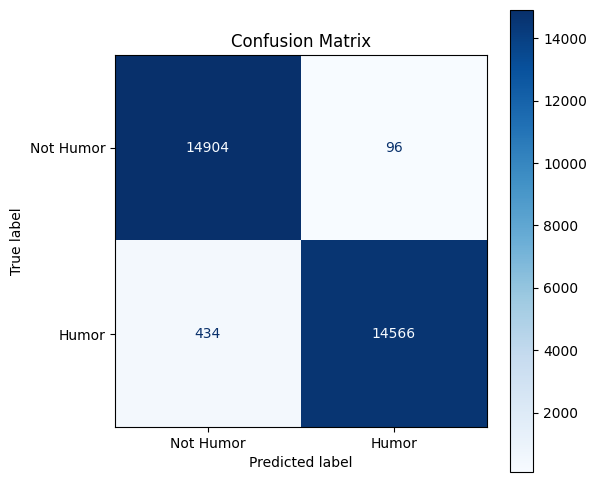

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

def test(model, test_loader, device):
    model.eval()

    test_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            # move batch tensors to GPU
            batch = {key: value.to(device) for key, value in batch.items()}

            # forward pass
            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["labels"]
            )

            loss = outputs.loss
            logits = outputs.logits

            # running average loss
            test_loss += (loss.item() - test_loss) / (batch_idx + 1)

            # predictions
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)

    print(f"Test Loss: {test_loss:.6f}")
    print(f"Test Accuracy: {accuracy * 100:.2f}%")

    print("\nClassification Report:")
    print(classification_report(
        all_labels,
        all_preds,
        target_names=["Not Humor", "Humor"]
    ))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    print("Confusion Matrix:")
    print(cm)

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Humor", "Humor"]
    )

    fig, ax = plt.subplots(figsize=(6,6))
    disp.plot(ax=ax, cmap="Blues")

    plt.title("Confusion Matrix")
    plt.show()


test(model, test_loader,device)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


=== Baseline Pretrained RoBERTa ===
Test Loss: 0.690812
Test Accuracy: 56.11%

Classification Report:
              precision    recall  f1-score   support

   Not Humor       0.53      1.00      0.69     15000
       Humor       0.99      0.12      0.22     15000

    accuracy                           0.56     30000
   macro avg       0.76      0.56      0.46     30000
weighted avg       0.76      0.56      0.46     30000

Confusion Matrix:
[[14982    18]
 [13148  1852]]


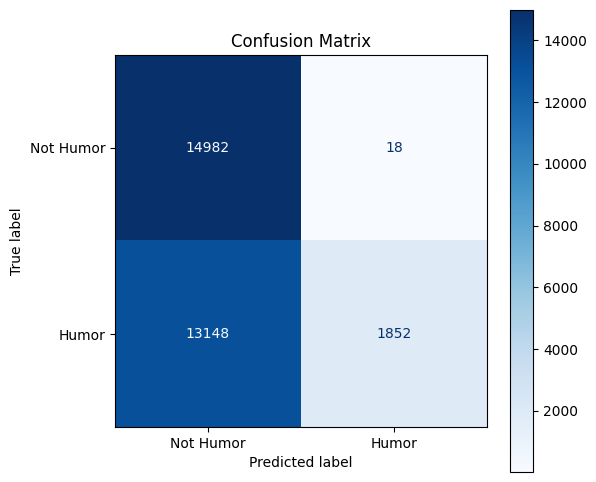

In [23]:
# Load unfine-tuned pretrained RoBERTa
baseline_model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

baseline_model.to(device)

# Test baseline model
print("=== Baseline Pretrained RoBERTa ===")
test(baseline_model, test_loader, device)

In [21]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 32.5 MB/s eta 0:00:00


Text: The past, the present and the future all walk into a bar. It was tense
Prediction: Humor
Confidence: 0.9916940331459045
Convergence delta: 25.672433853149414


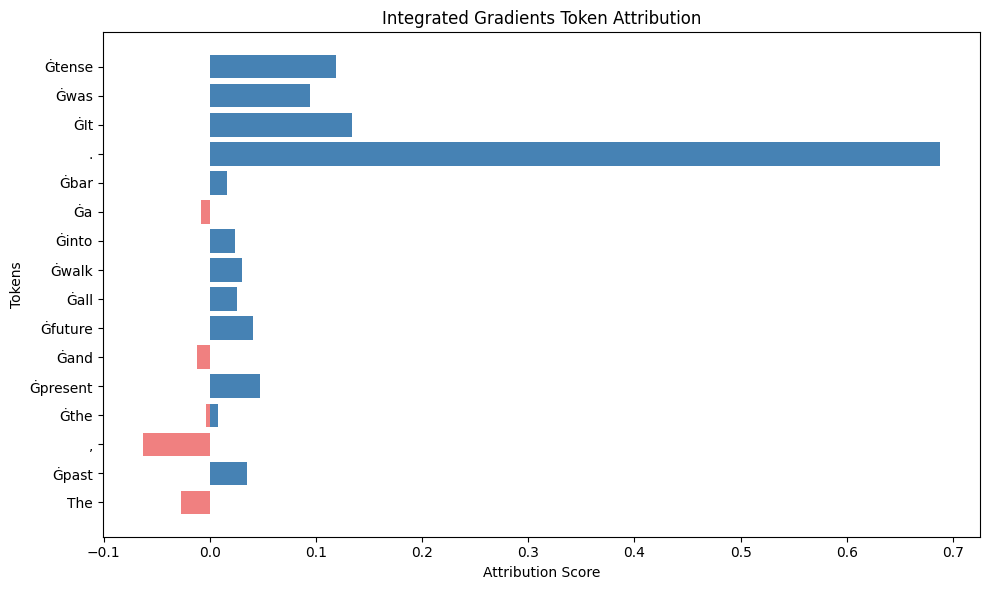

In [22]:
### XAI using Integrated Gradients ###
import matplotlib.pyplot as plt
from captum.attr import LayerIntegratedGradients

def explain_humor(model, tokenizer, text, device):

    # Tokenize the sample text
    encoding = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=128
    )

    # Move tensors to device
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    # Get prediction
    with torch.no_grad():

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Get logits
        logits = outputs.logits

        # Convert logits to probabilities
        probs = torch.softmax(logits, dim=1)

        # Predicted class
        pred_class = torch.argmax(probs, dim=1).item()

    # Forward pass function for Captum
    def forward_pass(input_ids, attention_mask):

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        return outputs.logits

    # Integrated Gradients
    lig = LayerIntegratedGradients(
        forward_pass,
        model.roberta.embeddings
    )

    # Baseline input = all PAD tokens
    baseline_ids = torch.full_like(
        input_ids,
        tokenizer.pad_token_id
    )

    # Compute attributions
    attributions, delta = lig.attribute(
        inputs=input_ids,
        baselines=baseline_ids,
        additional_forward_args=(attention_mask,),
        target=pred_class,
        return_convergence_delta=True
    )

    # Convert embedding attributions to token scores
    scores = attributions.sum(dim=-1).squeeze(0)

    # Normalize scores
    scores = scores / torch.norm(scores)

    # Convert ids to tokens
    tokens = tokenizer.convert_ids_to_tokens(
        input_ids.squeeze(0)
    )

    # Remove padding tokens
    valid_len = attention_mask.squeeze(0).sum().item()

    tokens = tokens[:valid_len]
    scores = scores[:valid_len].detach().cpu().numpy()

    # Print prediction information
    print("Text:", text)
    print("Prediction:", "Humor" if pred_class == 1 else "Not Humor")
    print("Confidence:", probs[0][pred_class].item())
    print("Convergence delta:", delta.item())

    # Remove special tokens from visualization
    filtered = [
        (tok, score)
        for tok, score in zip(tokens, scores)
        if tok not in ["<s>", "</s>", "<pad>"]
    ]

    tokens_filtered, scores_filtered = zip(*filtered)

    # Set colors based on attribution polarity
    colors = [
        "steelblue" if score > 0 else "lightcoral"
        for score in scores_filtered
    ]

    # Plot token attributions
    plt.figure(figsize=(10, 6))

    plt.barh(
        tokens_filtered,
        scores_filtered,
        color=colors
    )

    plt.xlabel("Attribution Score")
    plt.ylabel("Tokens")

    plt.title("Integrated Gradients Token Attribution")

    plt.tight_layout()
    plt.show()

    return tokens, scores

text1 = "My family tree is a cactus, we're all pricks."
text2 = "I'm a grown man, and I've got grown man problems!"
text3 = "I'm so good-looking, I make a mirror look like a masterpiece"
text4 = "I used to be a banker but I lost interest."
text5 = "The past, the present and the future all walk into a bar. It was tense"

tokens, scores = explain_humor(model,tokenizer, text5, device)
